In [8]:
!pip install tf-levenberg-marquardt 

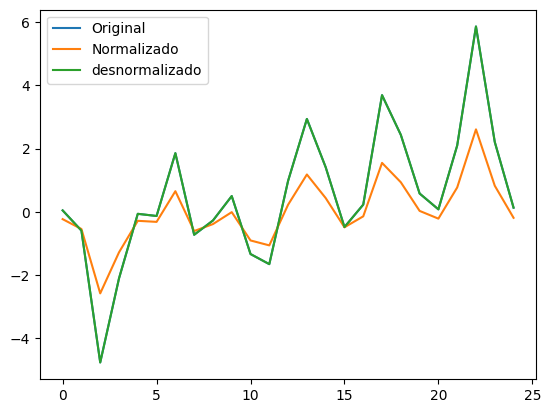

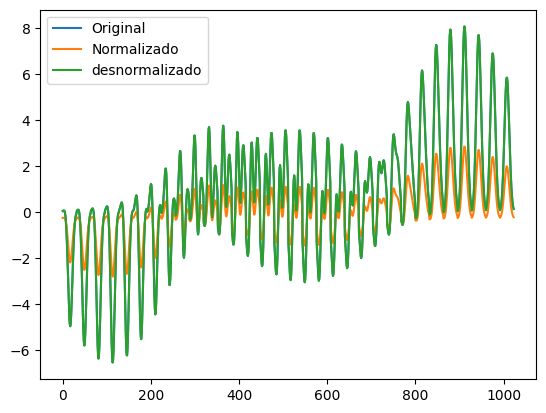

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [10]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [11]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


In [12]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [13]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [14]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 1.5,
            hidden_sizes = [[10], [11], [12], [13], [14]],
            regularizers=[0.2, 0.05],
            learning_rate=[0.01, 0.1]) 

Testando combinacao1: Hidden Size=[10], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++


Stopped at epoch:  7
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_2_8,0.809088,0.712270,0.149730,0.917353,0.708261,1.276631,1.924051,1.729450,0.421837,1.075644,1.877795,1.129881,1.269523,1.177982,81.511552,131.485460
model_1_2_7,0.805517,0.709493,0.137028,0.916334,0.704053,1.300510,1.942620,1.755284,0.427036,1.091160,1.894951,1.140399,1.274565,1.188948,81.474486,131.448395
model_1_2_6,0.801844,0.706625,0.123940,0.915102,0.699590,1.325073,1.961800,1.781905,0.433324,1.107615,1.912349,1.151118,1.279750,1.200124,81.437065,131.410973
model_1_2_5,0.798066,0.703663,0.110457,0.913650,0.694865,1.350335,1.981610,1.809330,0.440737,1.125034,1.929995,1.162039,1.285084,1.211509,81.399295,131.373204
model_1_2_4,0.794181,0.700604,0.096572,0.911970,0.689873,1.376310,2.002065,1.837572,0.449310,1.143441,1.947887,1.173162,1.290567,1.223106,81.361188,131.335096
model_1_2_3,0.790188,0.697445,0.082280,0.910056,0.684605,1.403016,2.023184,1.866643,0.459082,1.162862,1.966033,1.184490,1.296206,1.234916,81.322752,131.296660
model_1_2_2,0.786082,0.694185,0.067570,0.907900,0.679056,1.430469,2.044984,1.896562,0.470086,1.183324,1.984434,1.196022,1.302001,1.246939,81.283996,131.257905
model_1_2_1,0.781863,0.690821,0.052441,0.905495,0.673218,1.458684,2.067483,1.927336,0.482362,1.204849,2.003091,1.207760,1.307958,1.259177,81.244930,131.218839
model_1_2_0,0.777527,0.687349,0.036883,0.902833,0.667084,1.487677,2.090701,1.958981,0.495948,1.227465,2.022004,1.219704,1.314079,1.271629,81.205568,131.179476


DataFrame salvo em content/results/metrics_1_2
+++++++++++ [1_3] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_3] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_3] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_3_24,0.869509,0.762436,0.474464,0.897488,0.797235,0.872595,1.588593,0.868369,0.537579,0.702974,1.418878,0.934128,1.184223,0.973896,82.272567,132.246475
model_1_3_23,0.868678,0.761596,0.474913,0.906439,0.804111,0.878152,1.594209,0.867626,0.490639,0.679133,1.426899,0.937098,1.185396,0.976992,82.259871,132.233780
model_1_3_22,0.867709,0.760655,0.474721,0.914810,0.810397,0.884632,1.600504,0.867944,0.446740,0.657342,1.435113,0.940549,1.186764,0.980590,82.245167,132.219076
model_1_3_21,0.866600,0.759611,0.473885,0.922599,0.816088,0.892044,1.607482,0.869326,0.405895,0.637611,1.443523,0.944481,1.188329,0.984689,82.228480,132.202389
model_1_3_20,0.865352,0.758465,0.472409,0.929806,0.821187,0.900391,1.615145,0.871764,0.368102,0.619933,1.452142,0.948889,1.190091,0.989285,82.209853,132.183762
model_1_3_19,0.863964,0.757217,0.470303,0.936433,0.825697,0.909673,1.623494,0.875245,0.333347,0.604296,1.460980,0.953768,1.192051,0.994372,82.189341,132.163249
model_1_3_18,0.862436,0.755866,0.467576,0.942486,0.829625,0.919888,1.632528,0.879751,0.301606,0.590678,1.474748,0.959108,1.194207,0.999939,82.167006,132.140915
model_1_3_17,0.860770,0.754412,0.464247,0.947970,0.832979,0.931035,1.642245,0.885250,0.272848,0.579049,1.494537,0.964901,1.196561,1.005979,82.142918,132.116827
model_1_3_16,0.858965,0.752857,0.460337,0.952892,0.835770,0.943103,1.652644,0.891712,0.247035,0.569373,1.514472,0.971135,1.199108,1.012478,82.117160,132.091069
model_1_3_15,0.857023,0.751201,0.455872,0.957260,0.838009,0.956086,1.663720,0.899089,0.224133,0.561611,1.534540,0.977797,1.201850,1.019423,82.089815,132.063724


...

DataFrame salvo em content/results/metrics_20_7
+++++++++++ [20_8] | 1 ++++++++++++++++++
Stopped at epoch:  119
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [20_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 6 ++++++++++++++++++
Stopped at epoch:  10
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_8] | 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_20_8_0,0.934214,0.754316,0.633319,0.072407,0.320571,0.439909,1.642889,0.363525,2.385906,1.374716,0.606071,0.663256,1.047844,0.691493,115.642375,185.118297
model_20_8_1,0.934214,0.754316,0.633318,0.072407,0.320570,0.439909,1.642889,0.363526,2.385906,1.374717,0.606071,0.663257,1.047844,0.691493,115.642373,185.118295
model_20_8_2,0.934214,0.754316,0.633318,0.072407,0.320570,0.439910,1.642889,0.363526,2.385906,1.374717,0.606073,0.663257,1.047844,0.691493,115.642372,185.118294
model_20_8_12,0.934214,0.754316,0.633315,0.072407,0.320570,0.439910,1.642889,0.363529,2.385906,1.374717,0.606073,0.663257,1.047844,0.691493,115.642372,185.118294
model_20_8_3,0.934214,0.754316,0.633318,0.072407,0.320571,0.439909,1.642889,0.363526,2.385908,1.374716,0.606074,0.663256,1.047844,0.691493,115.642374,185.118296
model_20_8_11,0.934214,0.754316,0.633315,0.072407,0.320570,0.439909,1.642889,0.363529,2.385906,1.374717,0.606073,0.663257,1.047844,0.691493,115.642373,185.118295
model_20_8_14,0.934214,0.754316,0.633315,0.072407,0.320570,0.439910,1.642889,0.363529,2.385906,1.374718,0.606073,0.663257,1.047844,0.691493,115.642372,185.118294
model_20_8_22,0.934214,0.754316,0.633315,0.072407,0.320570,0.439910,1.642889,0.363529,2.385906,1.374718,0.606073,0.663257,1.047844,0.691493,115.642372,185.118294
model_20_8_21,0.934214,0.754316,0.633315,0.072407,0.320570,0.439910,1.642889,0.363529,2.385906,1.374718,0.606073,0.663257,1.047844,0.691493,115.642372,185.118294
model_20_8_20,0.934214,0.754316,0.633315,0.072407,0.320570,0.439910,1.642889,0.363529,2.385906,1.374718,0.606073,0.663257,1.047844,0.691493,115.642372,185.118294


DataFrame salvo em content/results/metrics_20_8
+++++++++++ [20_9] | 1 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 6ms/step
+++++++++++ [20_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [20_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [20_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 1s 18ms/step
+++++++++++ [20_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [20_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [20_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [20_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [20_9] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_20_9_3,0.947809,0.791254,0.893722,0.922128,0.926204,0.349001,1.395886,0.445056,0.785148,0.615102,2.435824,0.590763,1.037957,0.615913,116.105359,185.581281
model_20_9_4,0.942848,0.790930,0.854398,0.900028,0.902959,0.382174,1.398054,0.609735,1.007969,0.808852,2.638480,0.618202,1.041565,0.644521,115.923758,185.399680
model_20_9_2,0.951805,0.789762,0.930919,0.945326,0.949579,0.322282,1.405863,0.289288,0.551246,0.420266,2.176943,0.567699,1.035051,0.591867,116.264658,185.740580
model_20_9_5,0.937554,0.789451,0.815203,0.879878,0.880925,0.417577,1.407941,0.773870,1.211134,0.992502,2.827975,0.646202,1.045415,0.673712,115.746573,185.222495
model_20_9_6,0.932277,0.787285,0.777497,0.861920,0.860592,0.452863,1.422424,0.931771,1.392192,1.161981,2.981815,0.672951,1.049253,0.701600,115.584332,185.060254
model_20_9_1,0.953736,0.785614,0.962732,0.967547,0.971010,0.309366,1.433603,0.156067,0.327210,0.241639,1.829118,0.556207,1.033646,0.579886,116.346458,185.822380
model_20_9_7,0.927200,0.784743,0.742004,0.846091,0.842103,0.486813,1.439422,1.080405,1.551782,1.316094,3.109162,0.697720,1.052945,0.727423,115.439750,184.915672
model_20_9_8,0.922409,0.782027,0.709045,0.832197,0.825420,0.518854,1.457585,1.218423,1.691877,1.455150,3.216213,0.720315,1.056430,0.750980,115.312267,184.788189
model_20_9_9,0.917938,0.779268,0.678707,0.820005,0.810425,0.548750,1.476036,1.345471,1.814796,1.580134,3.307267,0.740777,1.059682,0.772313,115.200223,184.676145
model_20_9_0,0.951899,0.777911,0.985658,0.984758,0.987178,0.321650,1.485111,0.060061,0.153681,0.106871,1.373184,0.567142,1.034982,0.591287,116.268580,185.744502


DataFrame salvo em content/results/metrics_20_9
